In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Using device for CF / LightGCN: cuda
ratings.csv shape: (26024289, 4)
movies_metadata.csv shape: (45466, 24)
links.csv shape: (45843, 3)
Global users: 265072 Global items: 32028
Users with non-empty train interactions: 265072
Cold users (0 < interactions <= 10): 99931
Warm users (> 10 interactions): 155506
CF subset users: 8000, items: 28374
A_hat nnz: 6749520


LightGCN training (CF subset):   0%|          | 0/50 [00:00<?, ?it/s]


⏹ Early stopping at epoch 12 (no NDCG improvement).

✅ Training finished. Best validation NDCG@10 (CF subset, sampled): 0.4449


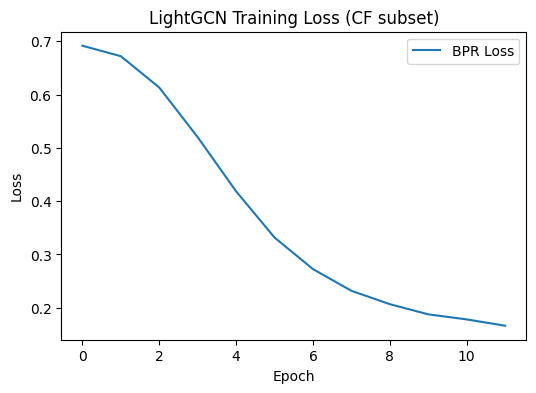

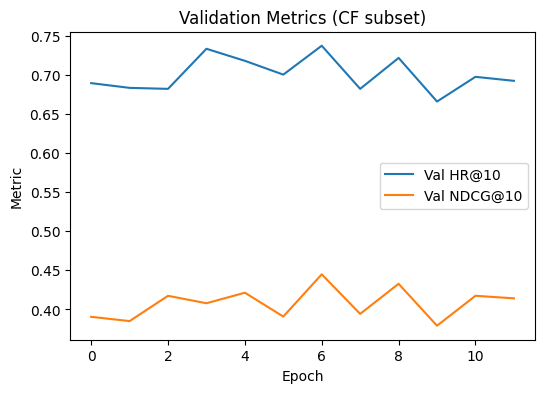

Using device for semantic RAG: cuda


Encoding CF items:   0%|          | 0/111 [00:00<?, ?it/s]


📊 Evaluating CF subset (ALL metrics)...


CF-only users:   0%|          | 0/300 [00:00<?, ?it/s]

CF-only -> P@10: 0.0690, R@10: 0.6900, HR@10: 0.6900, NDCG@10: 0.3949, AUC: 0.9013


...

Popularity-only (cold users) -> P@10: 0.0887, R@10: 0.8867, HR@10: 0.8867, NDCG@10: 0.6064, AUC: 0.9620


Semantic RAG (cold users) (cold users):   0%|          | 0/300 [00:00<?, ?it/s]

Semantic RAG (cold users) -> P@10: 0.0173, R@10: 0.1733, HR@10: 0.1733, NDCG@10: 0.0871, AUC: 0.6039


MEC-Semantic (cold users) (cold users):   0%|          | 0/300 [00:00<?, ?it/s]

MEC-Semantic (cold users) -> P@10: 0.0223, R@10: 0.2233, HR@10: 0.2233, NDCG@10: 0.1148, AUC: 0.6202

=== CF SUBSET SUMMARY (sampled) ===
CF-only: {'precision': 0.069, 'recall': 0.69, 'hitrate': 0.69, 'ndcg': 0.39485829419397467, 'auc': 0.9013468013468012}
Semantic-only (CF): {'precision': 0.011000000000000001, 'recall': 0.11, 'hitrate': 0.11, 'ndcg': 0.060527503807548795, 'auc': 0.5730976430976431}
Hybrid: {'precision': 0.06533333333333334, 'recall': 0.6533333333333333, 'hitrate': 0.6533333333333333, 'ndcg': 0.40073598719024567, 'auc': 0.9060942760942762}
MEC-Hybrid: {'precision': 0.07266666666666667, 'recall': 0.7266666666666667, 'hitrate': 0.7266666666666667, 'ndcg': 0.41804047682570505, 'auc': 0.9134006734006734}

=== TRUE COLD-START SUMMARY (global) ===
Popularity-only: {'precision': 0.08866666666666667, 'recall': 0.8866666666666667, 'hitrate': 0.8866666666666667, 'ndcg': 0.6064196455627445, 'auc': 0.961986531986532}
Semantic RAG: {'precision': 0.017333333333333336, 'recall': 0.17

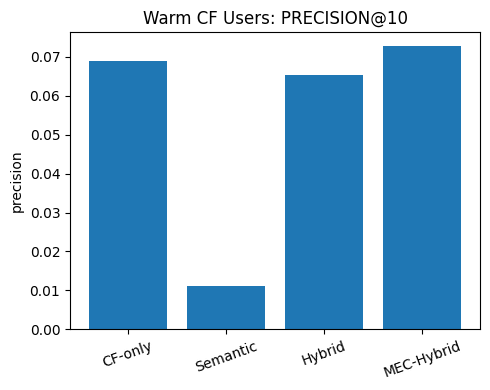

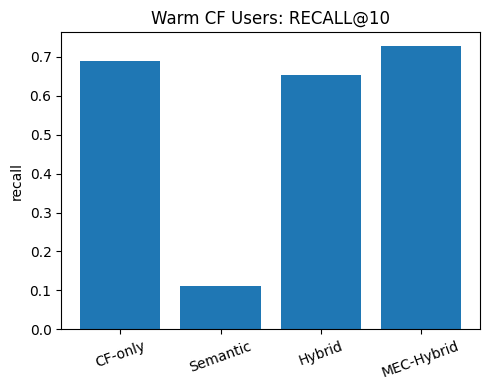

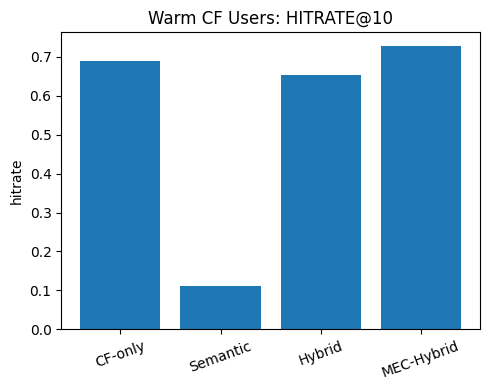

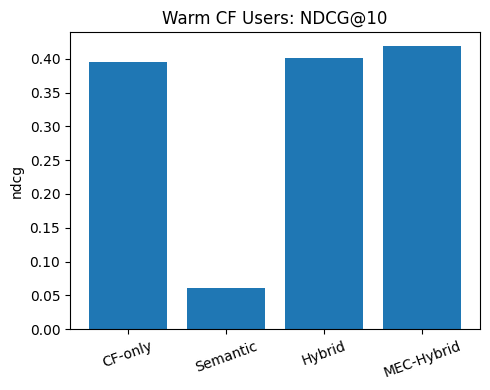

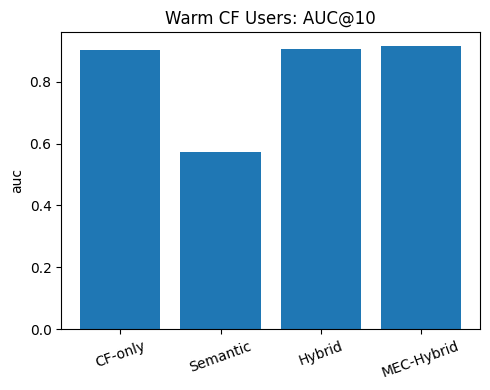

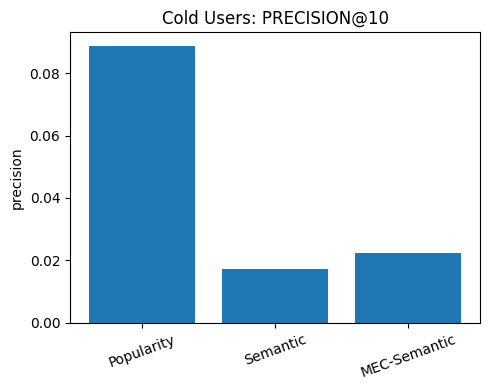

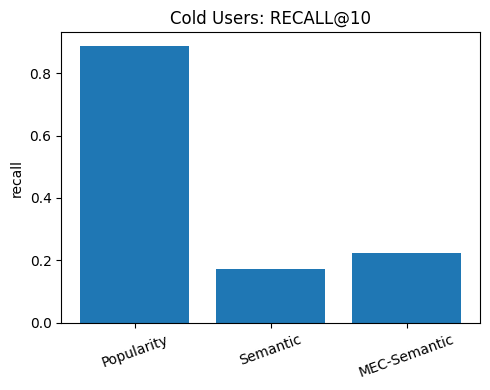

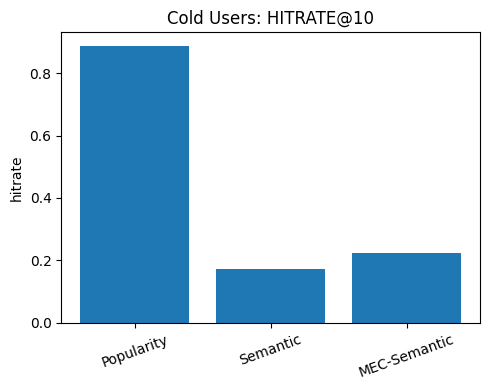

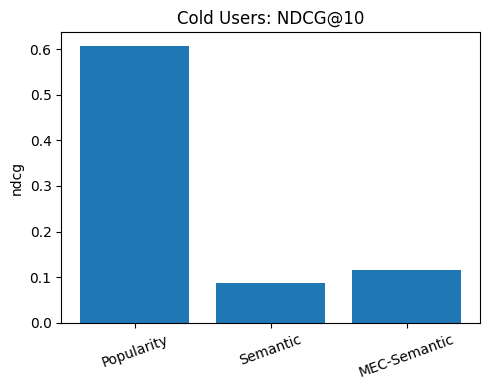

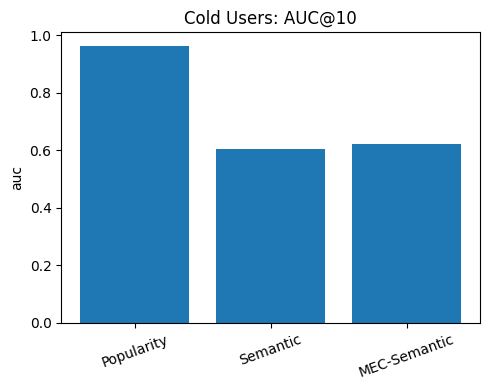


==================== RAG EXPLANATIONS (WARM USER, CF SUBSET) ====================
Title: Forrest Gump
Genres: romance, comedy, drama
Explanation: Retrieved (SBERT) metadata similar to The Gold Rush, Syndromes and a Century. Adaptive fusion uses n_u=3777: α=1.00 ⇒ fused=α·CF+(1−α)·SEM with CF=2.852, SEM=0.449. Genre evidence weight w_MEC=0.75 (overlap=3) refines the final rank.

Title: Fight Club
Genres: drama
Explanation: Retrieved (SBERT) metadata similar to Night and the City, The Chaos Class. Adaptive fusion uses n_u=3777: α=1.00 ⇒ fused=α·CF+(1−α)·SEM with CF=2.830, SEM=0.431. Genre evidence weight w_MEC=0.71 (overlap=1) refines the final rank.

Title: Braveheart
Genres: history, war, action, drama
Explanation: Retrieved (SBERT) metadata similar to Home of the Brave, Unforgiven. Adaptive fusion uses n_u=3777: α=1.00 ⇒ fused=α·CF+(1−α)·SEM with CF=2.646, SEM=0.512. Genre evidence weight w_MEC=0.76 (overlap=4) refines the final rank.

Title: The Fugitive
Genres: mystery, thriller, a

In [6]:
# ============================================================
# ASR-RAG (Your Same Pipeline) + ✅ FIXES + ✅ RAG EXPLANATIONS
# Fixes:
#   1) Correct MovieLens movieId -> TMDB id mapping using links.csv (prevents "Movie 1234")
#   2) Correct genre extraction using TMDB ids (prevents "Genres: none")
# Adds:
#   3) RAG-style explanations for top-N recommended items (warm + cold)
# Notes:
#   - Your evaluation/training logic is kept SAME (only corrected metadata + alpha fusion option)
#   - You can keep adaptive_alpha() if you want, or switch to sigmoid_alpha() (paper-consistent)
# ============================================================

import os, gc, math, random, ast
import numpy as np
import pandas as pd

import torch
from torch import nn
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from sentence_transformers import SentenceTransformer

# ============================================================
# 0. Setup
# ============================================================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device for CF / LightGCN:", device)

DATA_DIR = "/kaggle/input/the-movies-dataset"

# ============================================================
# 1. Load data
# ============================================================
ratings = pd.read_csv(os.path.join(DATA_DIR, "ratings.csv"))
movies  = pd.read_csv(os.path.join(DATA_DIR, "movies_metadata.csv"), low_memory=False)
links   = pd.read_csv(os.path.join(DATA_DIR, "links.csv"))  # ✅ MovieLens movieId -> TMDB id

print("ratings.csv shape:", ratings.shape)
print("movies_metadata.csv shape:", movies.shape)
print("links.csv shape:", links.shape)

ratings = ratings[["userId", "movieId", "rating", "timestamp"]]
ratings = ratings[ratings["rating"] >= 4.0].copy()
ratings = ratings.sort_values(["userId", "timestamp"])

# ============================================================
# ✅ FIX 1: MovieLens movieId -> TMDB id mapping (CRITICAL)
# ============================================================
links = links[["movieId", "tmdbId"]].copy()
links["movieId"] = pd.to_numeric(links["movieId"], errors="coerce").astype("Int64")
links["tmdbId"]  = pd.to_numeric(links["tmdbId"],  errors="coerce").astype("Int64")
links = links.dropna(subset=["movieId", "tmdbId"]).astype({"movieId": int, "tmdbId": int})
movieId_to_tmdb = dict(zip(links["movieId"].values, links["tmdbId"].values))

# Clean TMDB metadata
movies_meta = movies[["id", "title", "overview", "tagline", "genres"]].copy()
movies_meta["id"] = pd.to_numeric(movies_meta["id"], errors="coerce").astype("Int64")
movies_meta = movies_meta.dropna(subset=["id"]).astype({"id": int})

def parse_genres_safe(g_str):
    try:
        arr = ast.literal_eval(g_str)
        if isinstance(arr, list):
            out = []
            for d in arr:
                if isinstance(d, dict) and "name" in d:
                    nm = str(d["name"]).lower().strip()
                    if nm:
                        out.append(nm)
            return set(out)
    except Exception:
        pass
    return set()

tmdb_to_title  = dict(zip(movies_meta["id"].values, movies_meta["title"].fillna("").astype(str).values))
tmdb_to_text   = {}
tmdb_to_genres = {}

for _, row in movies_meta.iterrows():
    tid = int(row["id"])
    title = str(row["title"]) if pd.notnull(row["title"]) else ""
    overview = str(row["overview"]) if pd.notnull(row["overview"]) else ""
    tagline = str(row["tagline"]) if pd.notnull(row["tagline"]) else ""
    text = f"{title}. {overview} {tagline}".strip()
    text = " ".join(text.split())
    tmdb_to_text[tid]   = text if text else (title if title else "")
    tmdb_to_genres[tid] = parse_genres_safe(str(row["genres"]))

def get_tmdb_metadata_from_movielens(movie_id: int):
    """
    MovieLens movieId -> TMDB id -> (title, genres, text)
    Always returns non-empty fallback strings if missing.
    """
    tmdb = movieId_to_tmdb.get(int(movie_id), None)
    if tmdb is None:
        return f"Movie {movie_id}", set(), f"Movie {movie_id}"
    title = tmdb_to_title.get(tmdb, "") or f"Movie {movie_id}"
    genres = tmdb_to_genres.get(tmdb, set()) or set()
    text = tmdb_to_text.get(tmdb, "") or title
    return title, genres, text

# ============================================================
# Map to contiguous user/item indices (MovieLens item space)
# ============================================================
unique_users = ratings["userId"].unique()
user2idx = {u: i for i, u in enumerate(unique_users)}
idx2user = {i: u for u, i in user2idx.items()}

unique_items = ratings["movieId"].unique()
item2idx = {m: i for i, m in enumerate(unique_items)}
idx2item = {i: m for m, i in item2idx.items()}

ratings["user_idx"] = ratings["userId"].map(user2idx)
ratings["item_idx"] = ratings["movieId"].map(item2idx)

num_users_global = len(user2idx)
num_items_global = len(item2idx)
print(f"Global users: {num_users_global} Global items: {num_items_global}")

# ============================================================
# 2. Global leave-last-out split
# ============================================================
user_groups = ratings.groupby("user_idx")

train_glob, val_glob, test_glob, all_glob = {}, {}, {}, {}

for u, grp in user_groups:
    items = grp["item_idx"].tolist()
    if len(items) == 1:
        train, val, test = [items[0]], [], []
    elif len(items) == 2:
        train, val, test = [items[0]], [], [items[1]]
    else:
        train, val, test = items[:-2], [items[-2]], [items[-1]]

    train_glob[u] = set(train)
    val_glob[u] = set(val) if len(val) > 0 else set()
    test_glob[u] = set(test) if len(test) > 0 else set()
    all_glob[u] = set(items)

hist_len = {u: len(train_glob.get(u, set())) for u in train_glob}
non_empty_train_users = [u for u in hist_len if hist_len[u] > 0]
print("Users with non-empty train interactions:", len(non_empty_train_users))

cold_users_global = [u for u in non_empty_train_users if 0 < hist_len[u] <= 10 and len(test_glob[u]) > 0]
warm_users_global = [u for u in non_empty_train_users if hist_len[u] > 10 and len(test_glob[u]) > 0]

print(f"Cold users (0 < interactions <= 10): {len(cold_users_global)}")
print(f"Warm users (> 10 interactions): {len(warm_users_global)}")

# ============================================================
# 3. CF subset (top-K warm users)
# ============================================================
K_CF_USERS = 8000
warm_sorted = sorted(warm_users_global, key=lambda u: len(train_glob[u]), reverse=True)
cf_users_global = warm_sorted[:K_CF_USERS]

cf_user2cf = {u: i for i, u in enumerate(cf_users_global)}
cf_idx2user = {i: u for u, i in cf_user2cf.items()}

cf_item_set_global = set()
for u in cf_users_global:
    cf_item_set_global.update(train_glob[u])

cf_items_global_list = sorted(cf_item_set_global)
cf_item2cf = {it: i for i, it in enumerate(cf_items_global_list)}
cf_idx2item_global = {i: it for it, i in cf_item2cf.items()}

num_users_cf = len(cf_users_global)
num_items_cf = len(cf_items_global_list)
print(f"CF subset users: {num_users_cf}, items: {num_items_cf}")

train_cf, val_cf, test_cf = {}, {}, {}
for u_global in cf_users_global:
    u_cf = cf_user2cf[u_global]
    train_items = [cf_item2cf[it] for it in train_glob[u_global] if it in cf_item2cf]
    val_items   = [cf_item2cf[it] for it in val_glob[u_global] if it in cf_item2cf]
    test_items  = [cf_item2cf[it] for it in test_glob[u_global] if it in cf_item2cf]
    train_cf[u_cf] = set(train_items)
    val_cf[u_cf]   = set(val_items)
    test_cf[u_cf]  = set(test_items)

# ============================================================
# 4. Build normalized adjacency A_hat for LightGCN
# ============================================================
num_nodes = num_users_cf + num_items_cf
rows, cols = [], []

for u_cf, items in train_cf.items():
    for it_cf in items:
        v = num_users_cf + it_cf
        rows.append(u_cf); cols.append(v)
        rows.append(v);   cols.append(u_cf)

indices = torch.tensor([rows, cols], dtype=torch.long)
values  = torch.ones(len(rows), dtype=torch.float32)

adj = torch.sparse_coo_tensor(indices, values, (num_nodes, num_nodes)).coalesce()

deg = torch.sparse.sum(adj, dim=1).to_dense()
deg_inv_sqrt = torch.pow(deg + 1e-8, -0.5)
deg_inv_sqrt[torch.isinf(deg_inv_sqrt)] = 0.0

r, c = adj.indices()
v = adj.values()
norm_values = deg_inv_sqrt[r] * v * deg_inv_sqrt[c]

A_hat = torch.sparse_coo_tensor(torch.stack([r, c], dim=0), norm_values, (num_nodes, num_nodes)).coalesce().to(device)
print("A_hat nnz:", A_hat._nnz())

# ============================================================
# 5. LightGCN + BPR
# ============================================================
class LightGCN(nn.Module):
    def __init__(self, num_users, num_items, A_hat, embedding_dim=64, num_layers=3):
        super().__init__()
        self.num_users = num_users
        self.num_items = num_items
        self.num_layers = num_layers
        self.A_hat = A_hat
        self.user_emb = nn.Embedding(num_users, embedding_dim)
        self.item_emb = nn.Embedding(num_items, embedding_dim)
        nn.init.xavier_uniform_(self.user_emb.weight)
        nn.init.xavier_uniform_(self.item_emb.weight)

    def forward(self):
        x0 = torch.cat([self.user_emb.weight, self.item_emb.weight], dim=0)
        embs = [x0]
        x = x0
        for _ in range(self.num_layers):
            x = torch.sparse.mm(self.A_hat, x)
            embs.append(x)
        out = torch.stack(embs, dim=0).mean(dim=0)
        return out[:self.num_users], out[self.num_users:]

    def get_user_item_embeddings(self):
        return self.forward()

def bpr_loss(u_emb, pos_emb, neg_emb, l2_reg=1e-4):
    pos_scores = torch.sum(u_emb * pos_emb, dim=-1)
    neg_scores = torch.sum(u_emb * neg_emb, dim=-1)
    loss = -torch.mean(torch.log(torch.sigmoid(pos_scores - neg_scores) + 1e-8))
    if l2_reg > 0:
        loss = loss + l2_reg * (u_emb.norm(2).pow(2) + pos_emb.norm(2).pow(2) + neg_emb.norm(2).pow(2)) / u_emb.shape[0]
    return loss

def sample_bpr_batch(train_dict, num_items, batch_size=2048):
    users = list(train_dict.keys())
    user_batch, pos_batch, neg_batch = [], [], []
    for _ in range(batch_size):
        u = np.random.choice(users)
        pos_items = list(train_dict[u])
        if not pos_items:
            continue
        pos = np.random.choice(pos_items)
        while True:
            neg = np.random.randint(0, num_items)
            if neg not in train_dict[u]:
                break
        user_batch.append(u); pos_batch.append(pos); neg_batch.append(neg)
    return (
        torch.tensor(user_batch, dtype=torch.long),
        torch.tensor(pos_batch, dtype=torch.long),
        torch.tensor(neg_batch, dtype=torch.long),
    )

# ============================================================
# 6. Ranking metrics
# ============================================================
def compute_ranking_metrics(scores, pos_idx, k=10):
    ranked_idx = np.argsort(-scores)
    topk = ranked_idx[:k]
    hit = 1.0 if pos_idx in topk else 0.0
    precision = hit / k
    recall = hit
    if hit:
        rank_pos = np.where(topk == pos_idx)[0][0]
        ndcg = 1.0 / np.log2(rank_pos + 2)
    else:
        ndcg = 0.0
    num_negs = len(scores) - 1
    full_rank_pos = np.where(ranked_idx == pos_idx)[0][0]
    negs_below = num_negs - full_rank_pos
    auc = negs_below / max(num_negs, 1)
    return precision, recall, hit, ndcg, auc

def aggregate_metrics(all_metrics):
    if len(all_metrics) == 0:
        return {"precision":0.0,"recall":0.0,"hitrate":0.0,"ndcg":0.0,"auc":0.0}
    arr = np.array(all_metrics)
    return {
        "precision": float(arr[:, 0].mean()),
        "recall":    float(arr[:, 1].mean()),
        "hitrate":   float(arr[:, 2].mean()),
        "ndcg":      float(arr[:, 3].mean()),
        "auc":       float(arr[:, 4].mean()),
    }

def evaluate_cf_sampled_metrics(user_emb, item_emb, train_dict, val_dict, num_items,
                               k=10, num_users_eval=500, num_negatives=99):
    users = list(val_dict.keys())
    if len(users) == 0:
        return aggregate_metrics([])
    if len(users) > num_users_eval:
        users = np.random.choice(users, size=num_users_eval, replace=False)

    U = user_emb.detach().cpu().numpy()
    V = item_emb.detach().cpu().numpy()
    all_metrics = []

    for u in users:
        if len(val_dict[u]) == 0:
            continue
        pos_item = list(val_dict[u])[0]
        user_all = train_dict[u] | val_dict[u]
        negs = []
        while len(negs) < num_negatives:
            cand = np.random.randint(0, num_items)
            if cand not in user_all:
                negs.append(cand)
        candidates = [pos_item] + negs
        cand_arr = np.array(candidates, dtype=int)
        scores = V[cand_arr] @ U[u]
        all_metrics.append(compute_ranking_metrics(scores, pos_idx=0, k=k))

    return aggregate_metrics(all_metrics)

# ============================================================
# 7. Train LightGCN
# ============================================================
EMB_DIM    = 64
NUM_LAYERS = 3
BPR_L2     = 1e-4
BATCH_SIZE = 4096
MAX_EPOCHS = 50
PATIENCE   = 5
K_EVAL     = 10

model_lgcn = LightGCN(num_users_cf, num_items_cf, A_hat, embedding_dim=EMB_DIM, num_layers=NUM_LAYERS).to(device)
optimizer = torch.optim.Adam(model_lgcn.parameters(), lr=1e-3)

history_loss, history_hr, history_ndcg = [], [], []
best_ndcg, best_state, no_improve = -1.0, None, 0

epoch_bar = tqdm(range(1, MAX_EPOCHS + 1), desc="LightGCN training (CF subset)")

for epoch in epoch_bar:
    model_lgcn.train()
    total_loss = 0.0
    NUM_BATCHES = 20

    for _ in range(NUM_BATCHES):
        user_batch, pos_batch, neg_batch = sample_bpr_batch(train_cf, num_items_cf, batch_size=BATCH_SIZE)
        user_batch = user_batch.to(device); pos_batch = pos_batch.to(device); neg_batch = neg_batch.to(device)

        user_emb, item_emb = model_lgcn.get_user_item_embeddings()
        loss = bpr_loss(user_emb[user_batch], item_emb[pos_batch], item_emb[neg_batch], l2_reg=BPR_L2)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / NUM_BATCHES

    model_lgcn.eval()
    with torch.no_grad():
        user_emb_eval, item_emb_eval = model_lgcn.get_user_item_embeddings()
        metrics_val = evaluate_cf_sampled_metrics(user_emb_eval, item_emb_eval, train_cf, val_cf, num_items_cf,
                                                  k=K_EVAL, num_users_eval=500, num_negatives=99)

    history_loss.append(avg_loss)
    history_hr.append(metrics_val["hitrate"])
    history_ndcg.append(metrics_val["ndcg"])

    epoch_bar.set_postfix({"loss": f"{avg_loss:.4f}", "HR@10": f"{metrics_val['hitrate']:.4f}", "NDCG@10": f"{metrics_val['ndcg']:.4f}"})

    if metrics_val["ndcg"] > best_ndcg + 1e-4:
        best_ndcg = metrics_val["ndcg"]
        best_state = {"user_emb": user_emb_eval.detach().cpu(), "item_emb": item_emb_eval.detach().cpu()}
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= PATIENCE:
            print(f"\n⏹ Early stopping at epoch {epoch} (no NDCG improvement).")
            break

print(f"\n✅ Training finished. Best validation NDCG@10 (CF subset, sampled): {best_ndcg:.4f}")

user_emb_cf = best_state["user_emb"]
item_emb_cf = best_state["item_emb"]

plt.figure(figsize=(6, 4))
plt.plot(history_loss, label="BPR Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("LightGCN Training Loss (CF subset)")
plt.legend(); plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history_hr, label="Val HR@10")
plt.plot(history_ndcg, label="Val NDCG@10")
plt.xlabel("Epoch"); plt.ylabel("Metric"); plt.title("Validation Metrics (CF subset)")
plt.legend(); plt.show()

# ============================================================
# 8. Sentence-BERT embeddings (✅ FIXED text content)
# ============================================================
print("Using device for semantic RAG:", device)
st_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

# Build CF item texts + titles + genres in CF index space
cf_item_titles, cf_item_texts, cf_item_genres = [], [], []
for i_cf in range(num_items_cf):
    global_item_idx = cf_idx2item_global[i_cf]
    movielens_movieId = int(idx2item[global_item_idx])
    title, genres, text = get_tmdb_metadata_from_movielens(movielens_movieId)
    cf_item_titles.append(title)
    cf_item_texts.append(text if text else title)
    cf_item_genres.append(genres)

BATCH = 256
cf_item_emb_sem = []
for i in tqdm(range(0, len(cf_item_texts), BATCH), desc="Encoding CF items"):
    batch_texts = cf_item_texts[i:i+BATCH]
    emb = st_model.encode(batch_texts, batch_size=BATCH, convert_to_numpy=True, show_progress_bar=False)
    cf_item_emb_sem.append(emb)
cf_item_emb_sem = np.vstack(cf_item_emb_sem).astype("float32")

# user semantic preference (CF subset)
user_sem_pref_cf = np.zeros((num_users_cf, cf_item_emb_sem.shape[1]), dtype="float32")
for u_cf in range(num_users_cf):
    u_global = cf_idx2user[u_cf]
    hist_items_global = list(train_glob[u_global])
    in_cf = [cf_item2cf[it] for it in hist_items_global if it in cf_item2cf]
    if not in_cf:
        continue
    emb = cf_item_emb_sem[in_cf].mean(axis=0)
    user_sem_pref_cf[u_cf] = emb / (np.linalg.norm(emb) + 1e-8)

# ============================================================
# 9. Genres evidence for MEC (✅ FIXED genres)
# ============================================================
user_genres_cf = []
for u_cf in range(num_users_cf):
    u_global = cf_idx2user[u_cf]
    gset_u = set()
    for it_global in train_glob[u_global]:
        movielens_movieId = int(idx2item[it_global])
        _t, g, _txt = get_tmdb_metadata_from_movielens(movielens_movieId)
        gset_u |= g
    user_genres_cf.append(gset_u)

def mec_weight(user_g, item_g, lam=0.3):
    if not user_g or not item_g:
        return 1.0 - lam
    inter = len(user_g & item_g)
    evidence = inter / max(len(user_g), 1)
    return (1.0 - lam) + lam * evidence

# ============================================================
# 9.1 Adaptive Fusion (keep your adaptive_alpha OR use sigmoid_alpha)
# ============================================================
def adaptive_alpha(hist_len, min_hist=3, max_hist=100, alpha_min=0.2, alpha_max=0.9):
    h = max(min_hist, min(max_hist, hist_len))
    t = (h - min_hist) / (max_hist - min_hist)
    return alpha_min + t * (alpha_max - alpha_min)

def sigmoid_alpha(n_u, n0=10, beta=0.5):
    return 1.0 / (1.0 + np.exp(-beta * (n_u - n0)))

USE_SIGMOID_ALPHA = True   # ✅ set False if you want your old alpha

# ============================================================
# 10. CF subset evaluation (same as yours but genre/text fixed)
# ============================================================
def eval_method_cf(
    method_name,
    user_emb_cf, item_emb_cf,
    cf_users_list,
    train_cf, test_cf,
    k=10, num_users_eval=300, num_negatives=99,
    mode="cf", lam=0.3, n0=10, beta=0.5
):
    if len(cf_users_list) == 0:
        print(f"No users for {method_name}")
        return aggregate_metrics([])

    users_eval = [u for u in cf_users_list if len(test_cf[u]) > 0 and len(train_cf[u]) > 0]
    if len(users_eval) == 0:
        print(f"No valid test users for {method_name}")
        return aggregate_metrics([])

    if len(users_eval) > num_users_eval:
        users_eval = list(np.random.choice(users_eval, size=num_users_eval, replace=False))

    user_emb_np = user_emb_cf.detach().cpu().numpy()
    item_emb_np = item_emb_cf.detach().cpu().numpy()

    all_metrics = []

    for u_cf in tqdm(users_eval, desc=f"{method_name} users", leave=False):
        pos_item = list(test_cf[u_cf])[0]
        user_all = train_cf[u_cf] | test_cf[u_cf]

        negs = []
        while len(negs) < num_negatives:
            cand = np.random.randint(0, num_items_cf)
            if cand not in user_all:
                negs.append(cand)

        candidates = [pos_item] + negs
        cand_arr = np.array(candidates, dtype=int)

        # CF scores
        cf_scores = np.dot(item_emb_np[cand_arr], user_emb_np[u_cf])

        # Semantic scores
        sem_scores = np.dot(cf_item_emb_sem[cand_arr], user_sem_pref_cf[u_cf])

        u_global = cf_idx2user[u_cf]
        hlen = len(train_glob[u_global])
        alpha = sigmoid_alpha(hlen, n0=n0, beta=beta) if USE_SIGMOID_ALPHA else adaptive_alpha(hlen)

        if mode == "cf":
            scores = cf_scores
        elif mode == "semantic":
            scores = sem_scores
        elif mode == "hybrid":
            scores = alpha * cf_scores + (1.0 - alpha) * sem_scores
        elif mode == "mec-hybrid":
            base = alpha * cf_scores + (1.0 - alpha) * sem_scores
            g_user = user_genres_cf[u_cf]
            weights = np.array([mec_weight(g_user, cf_item_genres[it], lam=lam) for it in cand_arr], dtype="float32")
            scores = base * weights
        else:
            scores = cf_scores

        all_metrics.append(compute_ranking_metrics(scores, pos_idx=0, k=k))

    agg = aggregate_metrics(all_metrics)
    print(f"{method_name} -> P@{k}: {agg['precision']:.4f}, "
          f"R@{k}: {agg['recall']:.4f}, HR@{k}: {agg['hitrate']:.4f}, "
          f"NDCG@{k}: {agg['ndcg']:.4f}, AUC: {agg['auc']:.4f}")
    return agg

cf_all_users = list(train_cf.keys())

print("\n📊 Evaluating CF subset (ALL metrics)...")
metrics_cf_only = eval_method_cf("CF-only", user_emb_cf, item_emb_cf, cf_all_users, train_cf, test_cf, k=K_EVAL, mode="cf")
metrics_sem_cf  = eval_method_cf("Semantic-only (CF)", user_emb_cf, item_emb_cf, cf_all_users, train_cf, test_cf, k=K_EVAL, mode="semantic")
metrics_hyb_cf  = eval_method_cf("Hybrid (CF + semantic)", user_emb_cf, item_emb_cf, cf_all_users, train_cf, test_cf, k=K_EVAL, mode="hybrid")
metrics_mec_cf  = eval_method_cf("MEC-Hybrid (CF + semantic + evidence)", user_emb_cf, item_emb_cf, cf_all_users, train_cf, test_cf, k=K_EVAL, mode="mec-hybrid")

# ============================================================
# 11. Global cold-start evaluation (Popularity, Semantic, MEC-Semantic) ✅ FIXED
# ============================================================
print("\nTotal global cold users with test interactions:", len(cold_users_global))

global_item_titles, global_item_texts, global_item_genres = [], [], []
for i in range(num_items_global):
    movielens_movieId = int(idx2item[i])
    title, genres, text = get_tmdb_metadata_from_movielens(movielens_movieId)
    global_item_titles.append(title)
    global_item_texts.append(text if text else title)
    global_item_genres.append(genres)

BATCH = 256
global_item_emb_sem = []
for i in tqdm(range(0, num_items_global, BATCH), desc="Encoding global items"):
    batch_texts = global_item_texts[i:i+BATCH]
    emb = st_model.encode(batch_texts, batch_size=BATCH, convert_to_numpy=True, show_progress_bar=False)
    global_item_emb_sem.append(emb)
global_item_emb_sem = np.vstack(global_item_emb_sem).astype("float32")

item_popularity = np.zeros(num_items_global, dtype=np.int64)
for u, items in train_glob.items():
    for it in items:
        item_popularity[it] += 1

def eval_cold_methods(method_name, cold_users, k=10, num_users_eval=300, num_negatives=99, mode="popularity", lam=0.3):
    if len(cold_users) == 0:
        print(f"No cold users for {method_name}")
        return aggregate_metrics([])

    users_eval = [u for u in cold_users if len(test_glob[u]) > 0 and len(train_glob[u]) > 0]
    if len(users_eval) == 0:
        print(f"No valid cold users for {method_name}")
        return aggregate_metrics([])

    if len(users_eval) > num_users_eval:
        users_eval = list(np.random.choice(users_eval, size=num_users_eval, replace=False))

    all_metrics = []

    for u_global in tqdm(users_eval, desc=f"{method_name} (cold users)", leave=False):
        pos_item = list(test_glob[u_global])[0]
        user_all = all_glob[u_global]

        negs = []
        while len(negs) < num_negatives:
            cand = np.random.randint(0, num_items_global)
            if cand not in user_all:
                negs.append(cand)

        candidates = [pos_item] + negs
        cand_arr = np.array(candidates, dtype=int)

        if mode == "popularity":
            scores = item_popularity[cand_arr].astype("float32")
        else:
            hist_items = list(train_glob[u_global])
            if len(hist_items) == 0:
                scores = item_popularity[cand_arr].astype("float32")
            else:
                u_emb = global_item_emb_sem[hist_items].mean(axis=0)
                u_emb = u_emb / (np.linalg.norm(u_emb) + 1e-8)
                sem_scores = np.dot(global_item_emb_sem[cand_arr], u_emb)

                if mode == "semantic":
                    scores = sem_scores
                elif mode == "mec-semantic":
                    g_user = set()
                    for it in hist_items:
                        g_user |= global_item_genres[it]
                    weights = np.array([mec_weight(g_user, global_item_genres[it], lam=lam) for it in cand_arr], dtype="float32")
                    scores = sem_scores * weights
                else:
                    scores = sem_scores

        all_metrics.append(compute_ranking_metrics(scores, pos_idx=0, k=k))

    agg = aggregate_metrics(all_metrics)
    print(f"{method_name} -> P@{k}: {agg['precision']:.4f}, "
          f"R@{k}: {agg['recall']:.4f}, HR@{k}: {agg['hitrate']:.4f}, "
          f"NDCG@{k}: {agg['ndcg']:.4f}, AUC: {agg['auc']:.4f}")
    return agg

print("\n📊 Evaluating TRUE COLD-START (global users) with ALL metrics...")
metrics_pop_cold = eval_cold_methods("Popularity-only (cold users)", cold_users_global, k=K_EVAL, mode="popularity")
metrics_sem_cold = eval_cold_methods("Semantic RAG (cold users)", cold_users_global, k=K_EVAL, mode="semantic")
metrics_mec_cold = eval_cold_methods("MEC-Semantic (cold users)", cold_users_global, k=K_EVAL, mode="mec-semantic")

print("\n=== CF SUBSET SUMMARY (sampled) ===")
print("CF-only:", metrics_cf_only)
print("Semantic-only (CF):", metrics_sem_cf)
print("Hybrid:", metrics_hyb_cf)
print("MEC-Hybrid:", metrics_mec_cf)

print("\n=== TRUE COLD-START SUMMARY (global) ===")
print("Popularity-only:", metrics_pop_cold)
print("Semantic RAG:", metrics_sem_cold)
print("MEC-Semantic:", metrics_mec_cold)

# ============================================================
# 12. Plots: Warm CF users and Cold users
# ============================================================
def plot_metric_bar(methods, metrics_list, metric_name, title):
    vals = [m[metric_name] for m in metrics_list]
    plt.figure(figsize=(5, 4))
    plt.bar(range(len(methods)), vals)
    plt.xticks(range(len(methods)), methods, rotation=20)
    plt.ylabel(metric_name)
    plt.title(title)
    plt.tight_layout()
    plt.show()

methods_warm = ["CF-only", "Semantic", "Hybrid", "MEC-Hybrid"]
metrics_warm = [metrics_cf_only, metrics_sem_cf, metrics_hyb_cf, metrics_mec_cf]
for m in ["precision", "recall", "hitrate", "ndcg", "auc"]:
    plot_metric_bar(methods_warm, metrics_warm, m, f"Warm CF Users: {m.upper()}@{K_EVAL}")

methods_cold = ["Popularity", "Semantic", "MEC-Semantic"]
metrics_cold = [metrics_pop_cold, metrics_sem_cold, metrics_mec_cold]
for m in ["precision", "recall", "hitrate", "ndcg", "auc"]:
    plot_metric_bar(methods_cold, metrics_cold, m, f"Cold Users: {m.upper()}@{K_EVAL}")

# ============================================================
# ✅ 13. RAG EXPLANATIONS (Warm + Cold)  (NEW SECTION)
# ============================================================
def format_genres(gset, maxn=6):
    if not gset:
        return "none"
    return ", ".join(list(gset)[:maxn])

def topk_similar_history_titles_cf(u_cf: int, cand_cf: int, k=2):
    """retrieve top-k most semantically similar items from user's history (CF subset)"""
    u_global = cf_idx2user[u_cf]
    hist_global = list(train_glob[u_global])
    hist_cf = [cf_item2cf[it] for it in hist_global if it in cf_item2cf]
    if len(hist_cf) == 0:
        return []
    cvec = cf_item_emb_sem[cand_cf]
    H = cf_item_emb_sem[np.array(hist_cf)]
    sims = H @ cvec
    top = np.argsort(-sims)[:k]
    return [cf_item_titles[hist_cf[i]] for i in top]

def explain_reco_warm(u_cf: int, cand_cf: int, cf_s: float, sem_s: float, alpha: float, w_mec: float):
    u_global = cf_idx2user[u_cf]
    n_u = len(train_glob[u_global])
    ctx = topk_similar_history_titles_cf(u_cf, cand_cf, k=2)
    ctx_str = ", ".join(ctx) if ctx else "your recent positives"
    g_item = cf_item_genres[cand_cf]
    g_user = user_genres_cf[u_cf]
    overlap = len(g_user & g_item) if g_user and g_item else 0
    return (
        f"Retrieved (SBERT) metadata similar to {ctx_str}. "
        f"Adaptive fusion uses n_u={n_u}: α={alpha:.2f} ⇒ fused=α·CF+(1−α)·SEM with "
        f"CF={cf_s:.3f}, SEM={sem_s:.3f}. "
        f"Genre evidence weight w_MEC={w_mec:.2f} (overlap={overlap}) refines the final rank."
    )

def recommend_with_explanations_warm(u_cf: int, topN=5, lam=0.3, n0=10, beta=0.5):
    U = user_emb_cf.detach().cpu().numpy()
    V = item_emb_cf.detach().cpu().numpy()

    seen = train_cf[u_cf] | val_cf.get(u_cf, set()) | test_cf.get(u_cf, set())
    candidates = np.array([i for i in range(num_items_cf) if i not in seen], dtype=int)
    if len(candidates) == 0:
        return []

    cf_scores  = V[candidates] @ U[u_cf]
    sem_scores = cf_item_emb_sem[candidates] @ user_sem_pref_cf[u_cf]

    u_global = cf_idx2user[u_cf]
    n_u = len(train_glob[u_global])
    alpha = sigmoid_alpha(n_u, n0=n0, beta=beta) if USE_SIGMOID_ALPHA else adaptive_alpha(n_u)

    base = alpha * cf_scores + (1.0 - alpha) * sem_scores

    g_user = user_genres_cf[u_cf]
    weights = np.array([mec_weight(g_user, cf_item_genres[it], lam=lam) for it in candidates], dtype="float32")
    final_scores = base * weights

    top_idx = np.argsort(-final_scores)[:topN]
    out = []
    for j in top_idx:
        it = int(candidates[j])
        out.append({
            "title": cf_item_titles[it],
            "genres": format_genres(cf_item_genres[it]),
            "explanation": explain_reco_warm(
                u_cf, it,
                cf_s=float(cf_scores[j]),
                sem_s=float(sem_scores[j]),
                alpha=float(alpha),
                w_mec=float(weights[j])
            )
        })
    return out

def explain_reco_cold(u_global: int, cand_global: int, sem_s: float, w_mec: float, pop: float):
    movielens_movieId = int(idx2item[cand_global])
    title, genres, _ = get_tmdb_metadata_from_movielens(movielens_movieId)
    return (
        f"Semantic retrieval (SBERT) score={sem_s:.3f} from liked-item metadata. "
        f"Genre evidence w_MEC={w_mec:.2f} adjusts confidence; popularity prior={pop:.1f}. "
        f"Genres: {format_genres(genres)}."
    )

def recommend_with_explanations_cold(u_global: int, topN=5, lam=0.3, num_candidates=2000):
    """
    Cold user: semantic + MEC (+ popularity as tie-breaker).
    We do a candidate pruning for speed: top popular candidates.
    """
    hist_items = list(train_glob[u_global])
    if len(hist_items) == 0:
        return []

    u_emb = global_item_emb_sem[hist_items].mean(axis=0)
    u_emb = u_emb / (np.linalg.norm(u_emb) + 1e-8)

    seen = all_glob[u_global]
    # candidate pruning by popularity
    pop_rank = np.argsort(-item_popularity)
    cand = [int(i) for i in pop_rank[:num_candidates] if i not in seen]
    cand_arr = np.array(cand, dtype=int)
    if len(cand_arr) == 0:
        return []

    sem_scores = global_item_emb_sem[cand_arr] @ u_emb

    g_user = set()
    for it in hist_items:
        g_user |= global_item_genres[it]

    weights = np.array([mec_weight(g_user, global_item_genres[it], lam=lam) for it in cand_arr], dtype="float32")
    final = sem_scores * weights + 0.0001 * item_popularity[cand_arr].astype("float32")  # tiny pop tie-breaker

    top_idx = np.argsort(-final)[:topN]
    out = []
    for j in top_idx:
        it = int(cand_arr[j])
        movielens_movieId = int(idx2item[it])
        title, genres, _ = get_tmdb_metadata_from_movielens(movielens_movieId)
        out.append({
            "title": title,
            "genres": format_genres(genres),
            "explanation": explain_reco_cold(
                u_global, it,
                sem_s=float(sem_scores[j]),
                w_mec=float(weights[j]),
                pop=float(item_popularity[it])
            )
        })
    return out

# ------------------------------
# DEMO PRINTING
# ------------------------------
print("\n==================== RAG EXPLANATIONS (WARM USER, CF SUBSET) ====================")
demo_u_cf = int(list(train_cf.keys())[0])
warm_recos = recommend_with_explanations_warm(demo_u_cf, topN=5, lam=0.3, n0=10, beta=0.5)
for r in warm_recos:
    print(f"Title: {r['title']}")
    print(f"Genres: {r['genres']}")
    print(f"Explanation: {r['explanation']}")
    print("\n" + "="*80)

print("\n==================== RAG EXPLANATIONS (COLD USER, GLOBAL) ====================")
if len(cold_users_global) > 0:
    demo_u_global = int(cold_users_global[0])
    cold_recos = recommend_with_explanations_cold(demo_u_global, topN=5, lam=0.3)
    for r in cold_recos:
        print(f"Title: {r['title']}")
        print(f"Genres: {r['genres']}")
        print(f"Explanation: {r['explanation']}")
        print("\n" + "="*80)
else:
    print("No cold users available for demo.")
